In [ ]:
from PIL import Image

In [1]:
import zipfile
import os
import cv2

zip_path = "/content/archive.zip"
extract_path = "extracted_images"

# Extract the ZIP file
try:
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)
except zipfile.BadZipFile:
    print(f"Error: The file at {zip_path} is not a valid ZIP file. Please ensure it's a correct and uncorrupted ZIP archive.")
    # Exit or handle the error as appropriate, for now, we'll stop further processing.
    exit()
except FileNotFoundError:
    print(f"Error: The file {zip_path} was not found. Please ensure the path is correct.")
    exit()

# Read all images
images = []

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            img_path = os.path.join(root, file)
            img = cv2.imread(img_path)

            if img is not None:
                images.append(img)

print("Total images loaded:", len(images))

Total images loaded: 1800


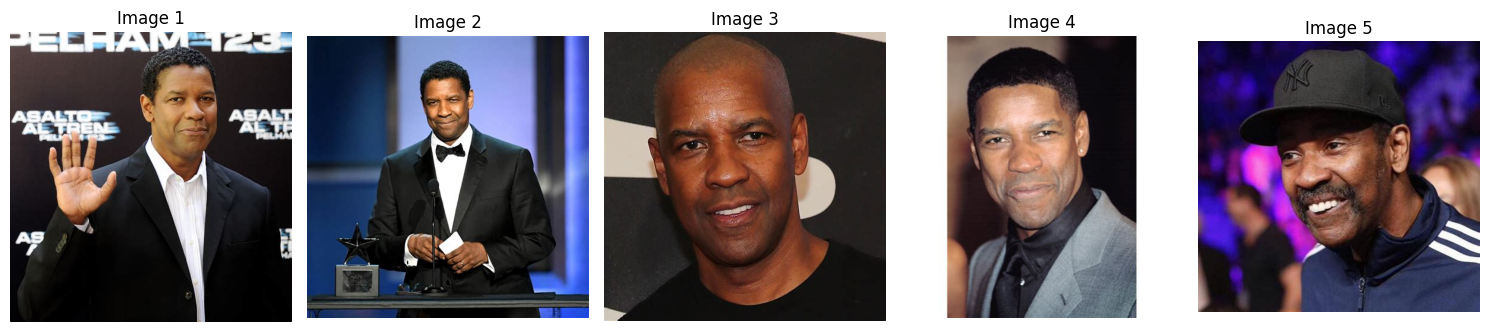

In [2]:
import matplotlib.pyplot as plt
import cv2

# Check if at least 5 images are available
if len(images) >= 5:

    plt.figure(figsize=(15, 8))

    for i in range(5):
        plt.subplot(1, 5, i + 1)

        # Convert BGR (OpenCV) to RGB (Matplotlib)
        img_rgb = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)

        plt.imshow(img_rgb)
        plt.title(f"Image {i+1}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

else:
    print("Less than 5 images found in the dataset.")

In [11]:
import pandas as pd

image_properties = []

for i, img in enumerate(images):
    if img is not None:
        height, width, channels = img.shape
        image_properties.append({"Image Index": i, "Height": height, "Width": width, "Channels": channels})

image_properties_df = pd.DataFrame(image_properties)
display(image_properties_df.head())

,Image Index,Height,Width,Channels
0,0,488,474,3
1,1,474,474,3
2,2,486,474,3
3,3,474,474,3
4,4,456,474,3


In [12]:
resized_images = []
target_size = (224, 224)

for img in images:
    if img is not None:
        # Resize the image using OpenCV
        resized_img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
        resized_images.append(resized_img)

print(f"Total images resized: {len(resized_images)}")

# Display the shape of the first resized image to verify
if resized_images:
    print(f"Shape of the first resized image: {resized_images[0].shape}")

Total images resized: 1800
Shape of the first resized image: (224, 224, 3)


In [13]:
grayscale_images = []
rgb_images = []
hsv_images = []

for img in resized_images:
    if img is not None:
        # Convert to Grayscale
        gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        grayscale_images.append(gray_img)

        # Convert to RGB (OpenCV reads as BGR by default)
        rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        rgb_images.append(rgb_img)

        # Convert to HSV
        hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        hsv_images.append(hsv_img)

print(f"Total grayscale images: {len(grayscale_images)}")
print(f"Total RGB images: {len(rgb_images)}")
print(f"Total HSV images: {len(hsv_images)}")

Total grayscale images: 1800
Total RGB images: 1800
Total HSV images: 1800


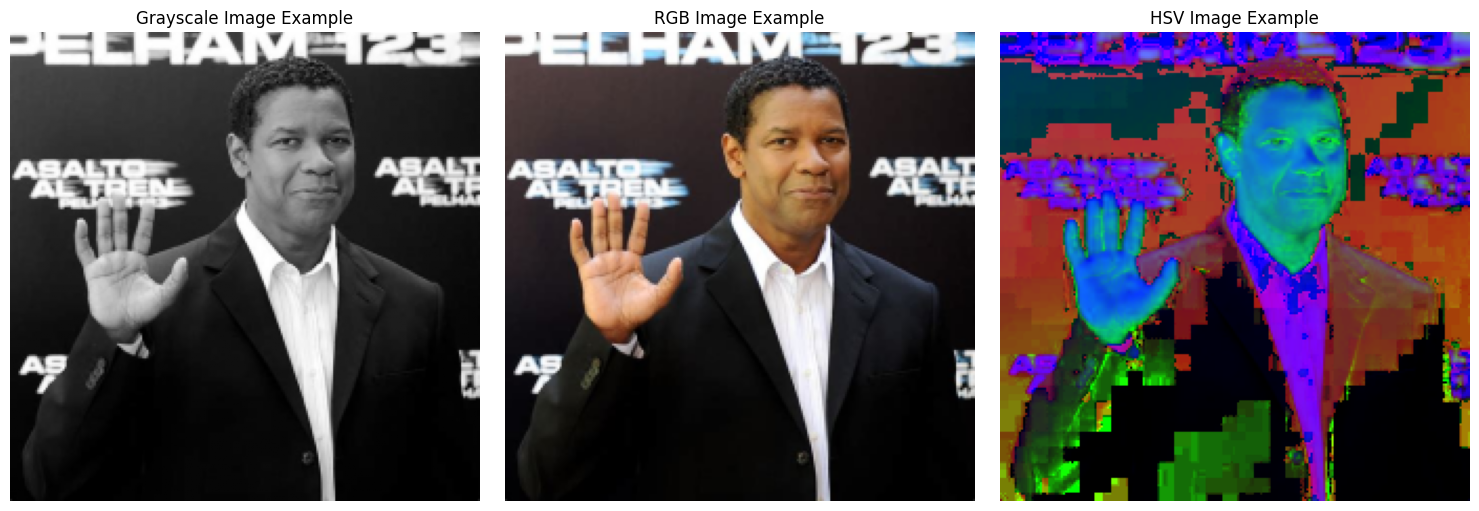

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

# Display a grayscale image
if grayscale_images:
    plt.subplot(1, 3, 1)
    plt.imshow(grayscale_images[0], cmap='gray')
    plt.title('Grayscale Image Example')
    plt.axis('off')

# Display an RGB image
if rgb_images:
    plt.subplot(1, 3, 2)
    plt.imshow(rgb_images[0])
    plt.title('RGB Image Example')
    plt.axis('off')

# Display an HSV image
if hsv_images:
    plt.subplot(1, 3, 3)
    plt.imshow(hsv_images[0])
    plt.title('HSV Image Example')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [15]:
normalized_images = []

for img in resized_images:
    if img is not None:
        # Convert image to float type and normalize to 0-1 range
        normalized_img = img.astype('float32') / 255.0
        normalized_images.append(normalized_img)

print(f"Total normalized images: {len(normalized_images)}")

# Verify normalization by checking min and max pixel values of the first image
if normalized_images:
    first_normalized_img = normalized_images[0]
    print(f"Min pixel value of the first normalized image: {first_normalized_img.min()}")
    print(f"Max pixel value of the first normalized image: {first_normalized_img.max()}")

Total normalized images: 1800
Min pixel value of the first normalized image: 0.0
Max pixel value of the first normalized image: 1.0


In [16]:
import cv2
import numpy as np

def preprocess_image(image, target_size=(224, 224)):
    """
    Resizes an image and normalizes its pixel values to the 0-1 range.

    Args:
        image (numpy.ndarray): The input image (e.g., from cv2.imread).
        target_size (tuple): The desired output size (width, height).

    Returns:
        numpy.ndarray: The resized and normalized image with pixel values in [0, 1].
    """
    if image is None:
        return None

    # Resize the image
    resized_img = cv2.resize(image, target_size, interpolation=cv2.INTER_AREA)

    # Convert to float type and normalize to 0-1 range
    normalized_img = resized_img.astype('float32') / 255.0

    return normalized_img

print("Defined preprocess_image() function.")

Defined preprocess_image() function.


Shape of the preprocessed image: (224, 224, 3)
Min pixel value of the preprocessed image: 0.0
Max pixel value of the preprocessed image: 1.0


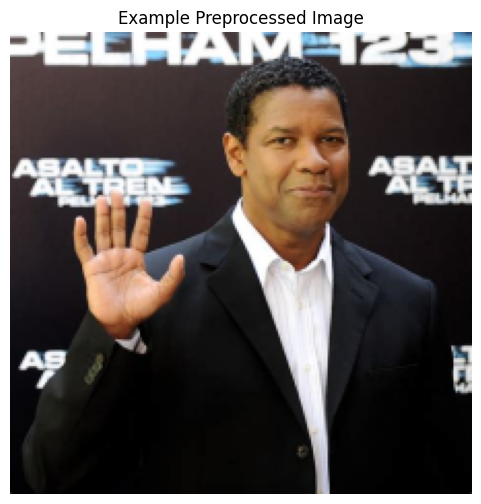

In [17]:
# Take the first raw image from the 'images' list
example_raw_image = images[0]

# Preprocess the example image
example_preprocessed_image = preprocess_image(example_raw_image)

# Display properties of the preprocessed image to verify
if example_preprocessed_image is not None:
    print(f"Shape of the preprocessed image: {example_preprocessed_image.shape}")
    print(f"Min pixel value of the preprocessed image: {example_preprocessed_image.min()}")
    print(f"Max pixel value of the preprocessed image: {example_preprocessed_image.max()}")

    # Visualize the preprocessed image
    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(example_preprocessed_image, cv2.COLOR_BGR2RGB)) # Convert back to RGB for display
    plt.title('Example Preprocessed Image')
    plt.axis('off')
    plt.show()
else:
    print("Preprocessing failed for the example image.")

In [ ]:
# Install albumentations, a modern data augmentation library
!pip install albumentations opencv-python-headless

In [18]:
import albumentations as A
import numpy as np
import matplotlib.pyplot as plt
import cv2 # Import cv2 for border_mode

# Define an augmentation pipeline using Albumentations
# Albumentations expects images to be float32 in [0, 1] range.
# Our images are already float32 in [0, 1] range.
augmentation_pipeline = A.Compose([
    A.HorizontalFlip(p=0.5), # horizontally flip 50% of all images
    A.VerticalFlip(p=0.2),   # vertically flip 20% of all images
    A.ShiftScaleRotate(
        shift_limit=0.2, scale_limit=0.2, rotate_limit=25, # shift, scale, rotate
        p=0.7, border_mode=cv2.BORDER_REFLECT_101 # default border mode for albumentations
    ),
    A.RandomBrightnessContrast(
        brightness_limit=0.2, contrast_limit=0.2, p=0.7 # brightness/contrast adjustment
    ),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.3) # add gaussian noise
])

# Apply augmentation
augmented_images = []
for img in normalized_images:
    if img is not None:
        # Albumentations expects images in a numpy array with shape (H, W, C) or (H, W)
        # and pixel values usually in [0, 1] for float.
        augmented = augmentation_pipeline(image=img)['image']
        augmented_images.append(augmented)

print(f"Original number of images: {len(normalized_images)}")
print(f"Number of augmented images: {len(augmented_images)}")

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_7086/3872298302.py:19: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.3) # add gaussian noise


Original number of images: 1800
Number of augmented images: 1800


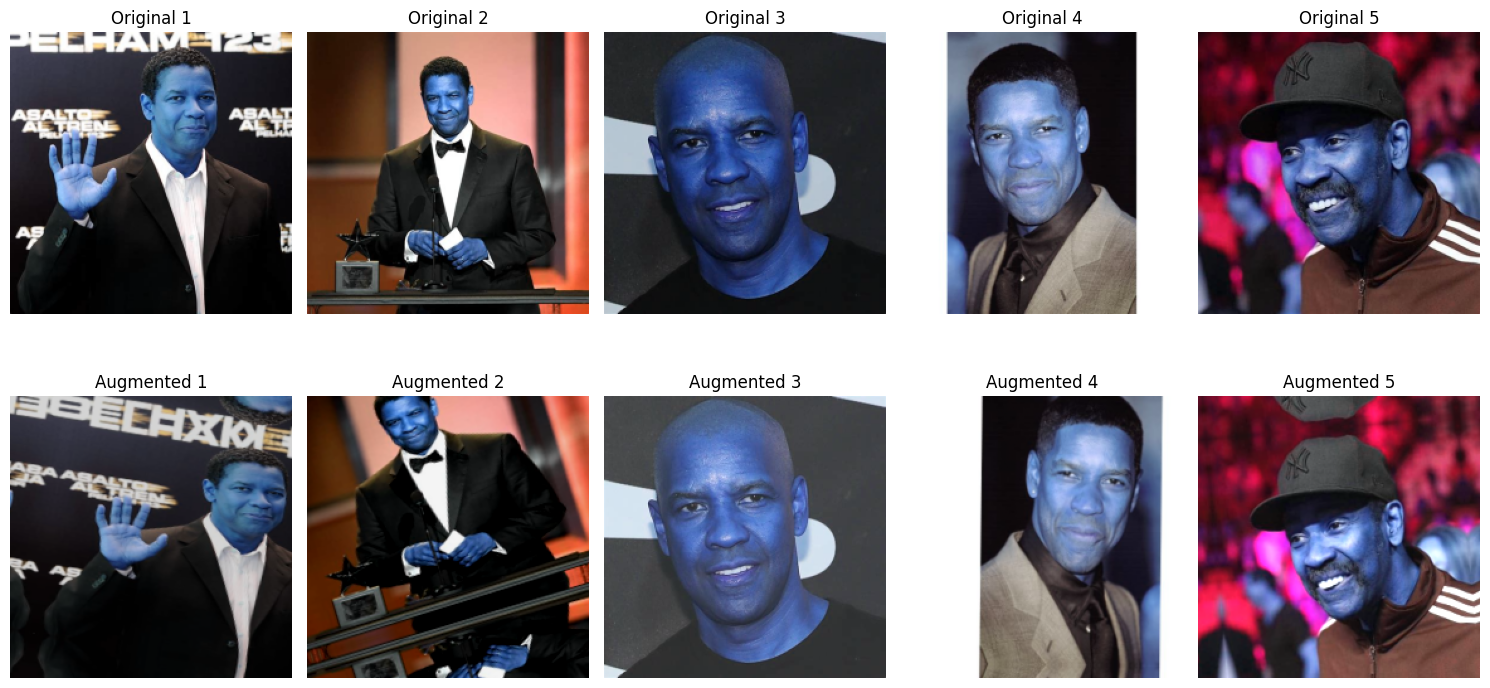

In [19]:
plt.figure(figsize=(15, 8))

num_display = 5 # Number of images to display

for i in range(num_display):
    # Original Image
    plt.subplot(2, num_display, i + 1)
    plt.imshow(normalized_images[i])
    plt.title(f"Original {i+1}")
    plt.axis('off')

    # Augmented Image
    plt.subplot(2, num_display, i + 1 + num_display)
    plt.imshow(augmented_images[i])
    plt.title(f"Augmented {i+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()